# Logistic Regression (Baseline)

This notebook trains a Logistic Regression Model on the kkbox churn dataset. The goal is to establish an interpretable starting point for identifying churn risk before comparing with more complex models.

# 1. Load dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#Loading the dataset 
df = pd.read_csv("kkbox_dataset_training.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (970960, 51)
                                           msno  target  transaction_count  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=       1                6.0   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=       1                5.0   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=       1               18.0   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=       1               18.0   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=       1               24.0   

   avg_payment_method  avg_plan_days  total_plan_list_price  \
0           32.166667        30.0000                  298.0   
1           37.000000        25.4000                  627.0   
2           38.000000        30.0000                 2682.0   
3           40.666667        28.5625                 2235.0   
4           41.000000        30.0000                 2529.0   

   total_actual_paid  avg_actual_paid  discount_frequency  renewal_rate  ...  \
0              894.0       149.000000               

# 2. Basic Checks

In [2]:
#Checking number of rows and columns, datatypes, etc. 
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['msno', 'target', 'transaction_count', 'avg_payment_method', 'avg_plan_days', 'total_plan_list_price', 'total_actual_paid', 'avg_actual_paid', 'discount_frequency', 'renewal_rate', 'cancel_count', 'avg_days_to_expire', 'max_days_to_expire', 'first_transaction_x', 'last_transaction_x', 'last_expire_x', 'total_subscription_length', 'plan_category', 'total_discount', 'max_discount', 'avg_discount_pct', 'discount_bucket', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time_x', 'account_age_days_x', 'Loyalty_Status', 'Age_Group', 'City_Tier', 'total_listening_time', 'avg_daily_usage', 'total_unique_songs', 'total_sessions', 'num_log_days', 'last_log_date_x', 'num_25_sum', 'num_100_sum', 'completion_rate', 'skip_rate', 'first_transaction_y', 'last_transaction_y', 'last_expire_y', 'registration_init_time_y', 'last_log_date_y', 'membership_duration', 'days_since_last_transaction', 'time_until_expiration', 'account_age_days_y', 'days_since_last_log']
target
0    883630
1     8733

# 3. Define features and target


In [3]:
#Defining target variable y and feature set X
#'is_churn' is the label to be predicted
#'msno' is the user identifier

X = df.drop(columns=["target", "msno"], errors="ignore").copy()
y = df["target"].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

Initial X shape: (970960, 49)
Initial y shape: (970960,)


# 4. Handle missing values

In [4]:
#Check for missing values in the dataset

print("Missing values before fill:", X.isnull().sum().sum())
print(X.isnull().sum().sort_values(ascending=False).head(20))

# Fill numerical missing values with median (robust to outliers) and categorical missing values with 'Unknown'
df.fillna(df.median(numeric_only=True), inplace=True)

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Missing values after fill:", X.isnull().sum().sum())

Missing values before fill: 5761029
discount_bucket             932476
bd                          584359
Age_Group                   584359
days_since_last_log         218330
last_log_date_y             218330
total_unique_songs          216409
total_sessions              216409
num_log_days                216409
num_100_sum                 216409
completion_rate             216409
total_listening_time        216409
avg_daily_usage             216409
last_log_date_x             216409
num_25_sum                  216409
skip_rate                   216409
account_age_days_y          112025
registration_init_time_y    112025
Loyalty_Status              111900
registered_via              109993
account_age_days_x          109993
dtype: int64
Missing values after fill: 0


# 5. Encode categorical variables


In [5]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Shape after encoding:", X.shape)
X.head()

C:\Users\ADMIN 0\AppData\Local\Temp\ipykernel_3020\328541557.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


Shape after encoding: (970960, 49)


,transaction_count,avg_payment_method,avg_plan_days,total_plan_list_price,total_actual_paid,avg_actual_paid,discount_frequency,renewal_rate,cancel_count,avg_days_to_expire,...,first_transaction_y,last_transaction_y,last_expire_y,registration_init_time_y,last_log_date_y,membership_duration,days_since_last_transaction,time_until_expiration,account_age_days_y,days_since_last_log
0,6.0,32.166667,30.0000,298.0,894.0,149.000000,0.0,0.833333,1.0,25.166667,...,89,618,369,3553,28,730.0,1.0,29.0,1164.0,-28.0
1,5.0,37.000000,25.4000,627.0,627.0,125.400000,0.0,0.000000,0.0,31.000000,...,427,600,351,3553,19,374.0,19.0,11.0,1164.0,-19.0
2,18.0,38.000000,30.0000,2682.0,2682.0,149.000000,0.0,0.000000,0.0,30.611111,...,230,589,346,3557,30,566.0,30.0,6.0,1160.0,-30.0
3,18.0,40.666667,28.5625,2235.0,2533.0,140.722222,0.0,0.944444,2.0,356.944444,...,7,249,347,3570,31,790.0,370.0,7.0,1147.0,-30.0
4,24.0,41.000000,30.0000,2529.0,2956.0,123.166667,0.0,1.000000,2.0,182.708333,...,23,438,344,3586,30,771.0,181.0,4.0,1131.0,-30.0


# 6. Train-Test Split

In [6]:
#Splitting the data into training and testing sets
#Stratify ensures class distribution is preserved
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (776768, 49)
X_test: (194192, 49)


# 7. Logistic Regression Model

In [8]:


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# 8. Evaluate Model

In [9]:
#Evaluate model performance using classification metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

# Use SCALED test data
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8430

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91    176726
           1       0.34      0.76      0.47     17466

    accuracy                           0.84    194192
   macro avg       0.65      0.81      0.69    194192
weighted avg       0.92      0.84      0.87    194192


ROC-AUC: 0.8876301566493334

Confusion Matrix:
[[150389  26337]
 [  4152  13314]]


# 9. HyperTuning

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_log_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.8883006286796299


In [11]:

y_pred = best_log_model.predict(X_test_scaled)
y_prob = best_log_model.predict_proba(X_test_scaled)[:, 1]

print("TUNED LOGISTIC REGRESSION RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

TUNED LOGISTIC REGRESSION RESULTS
Accuracy: 0.8438

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91    176726
           1       0.34      0.76      0.47     17466

    accuracy                           0.84    194192
   macro avg       0.65      0.81      0.69    194192
weighted avg       0.92      0.84      0.87    194192


ROC-AUC: 0.8877380856342072

Confusion Matrix:
[[150574  26152]
 [  4177  13289]]


# 10. Top features

In [13]:
#Extracting feature importances to understand which variables drive churn predictions
#Higher importance = more influence on the model's decisions

feature_imp = pd.Series(
    log_model.coef_[0],   # coefficients for class 1
    index=X_train.columns
)

top_features = feature_imp.sort_values(ascending=False)

print("Top 10 Positive Features (increase churn):")
print(top_features.head(10))

print("\nTop 10 Negative Features (decrease churn):")
print(top_features.tail(10))

Top 10 Positive Features (increase churn):
days_since_last_log            10.734872
last_log_date_y                10.347974
membership_duration             1.556575
days_since_last_transaction     0.778242
first_transaction_y             0.760670
first_transaction_x             0.760670
total_plan_list_price           0.744890
time_until_expiration           0.486501
cancel_count                    0.380398
avg_actual_paid                 0.333163
dtype: float64

Top 10 Negative Features (decrease churn):
last_expire_y              -0.174487
total_sessions             -0.184427
avg_plan_days              -0.405881
last_transaction_y         -0.413035
last_transaction_x         -0.413035
transaction_count          -0.452392
total_actual_paid          -0.552762
account_age_days_x         -0.562628
renewal_rate               -0.772589
registration_init_time_x   -0.787756
dtype: float64


**Confusion Matrix Plot**

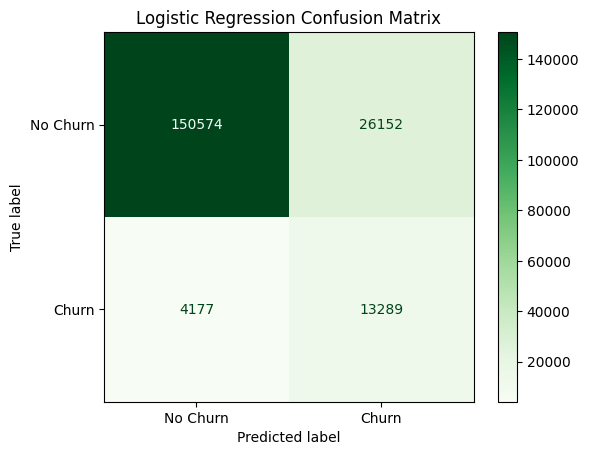

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**ROC Curve Plot**

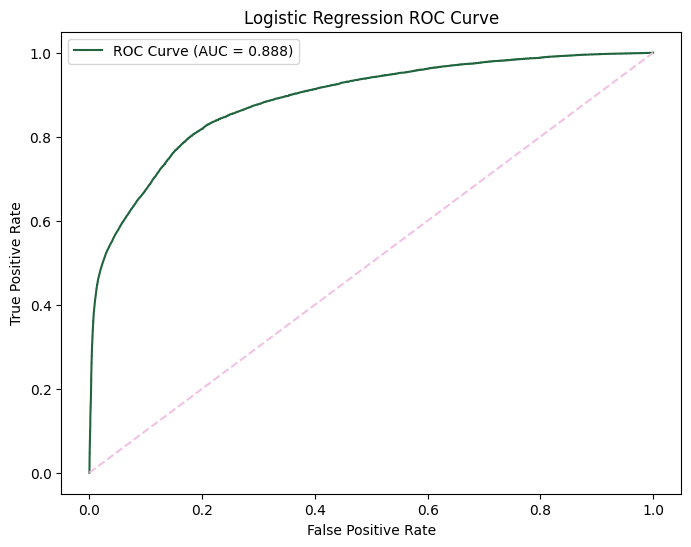

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    color="#21653e",   # soft green
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="#f1c2e6")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")

plt.legend()
plt.show()

**Top 15 Feature Importances Plot**

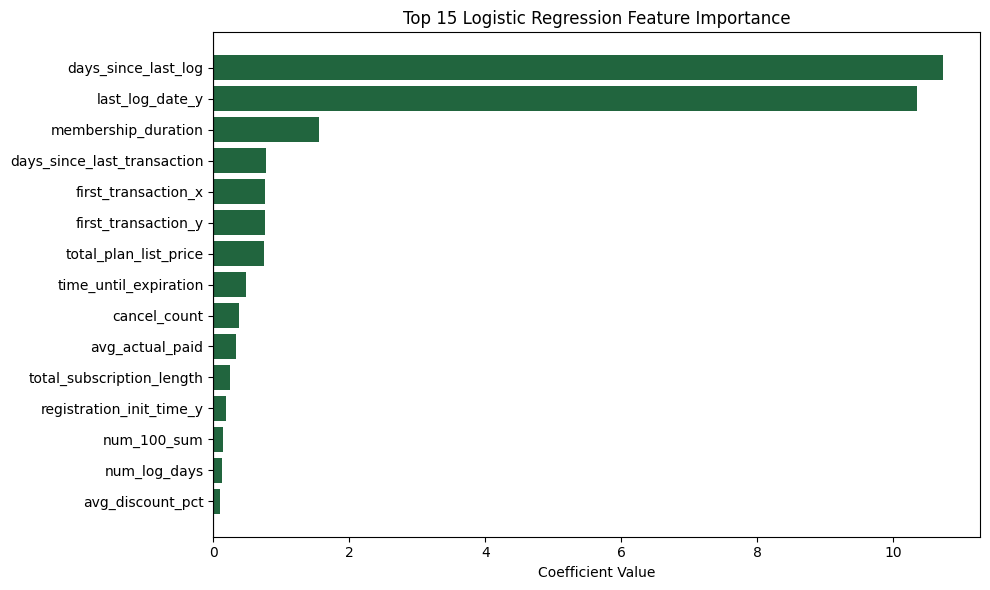

In [20]:
import matplotlib.pyplot as plt

# sort features
top15 = feature_imp.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top15.index, top15.values, color='#21653e')

plt.xlabel("Coefficient Value")
plt.title("Top 15 Logistic Regression Feature Importance")

plt.axvline(0, color='black')  # important for interpretation

plt.tight_layout()
plt.show()

# Insights
The Logistic Regression model confirms that behavioral features are the strongest predictors of churn. Features related to transaction frequency, renewal behavior, and cancellations have the highest impact on the model’s predictions, while demographic variables contribute less significantly.

Positive coefficients indicate factors that increase the likelihood of churn, such as high cancellation counts and inactivity, while negative coefficients indicate retention drivers, such as frequent transactions and auto-renewal.
